In [ ]:
import gc
import json
import os
import time

import numpy as np
import torch
import wandb
from torch.amp import autocast

from evaluation.neuroprobe import config as neuroprobe_config
from evaluation.neuroprobe.datasets import BrainTreebankSubjectTrialBenchmarkDataset
from evaluation.neuroprobe_tasks import FrozenModelEvaluation_SS_SM
from subject.dataset import load_subjects
from torch.optim.lr_scheduler import ChainedScheduler
from torch.utils.data import DataLoader
from training_setup.training_config import (
    convert_dtypes,
    get_default_config,
    log,
    parse_config_from_args,
    parse_subject_trials_from_config,
    unconvert_dtypes,
    update_dir_name,
    update_random_seed,
)
from optim import Muon


RUNS_DIR='runs/data'

### PARSE MODEL DIR ###
model_dir = "andrii0_lr0.003_wd0.0_dr0.2_rALL_ST1_t20250729_165436"  # Directory containing the saved model
model_epoch = 100  # Epoch of the model to load

### LOAD CONFIG ###

# Load the checkpoint
if model_epoch < 0: model_epoch = "final"
checkpoint_path = os.path.join(RUNS_DIR, model_dir, f"model_epoch_{model_epoch}.pth")
checkpoint = torch.load(checkpoint_path, map_location='cpu')
config = unconvert_dtypes(checkpoint['config'])
log(f"Directory name: {model_dir}", priority=0)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
config['device'] = device
log(f"Using device: {device}", priority=0)

config['cluster']['cache_subjects'] = False
subject_id, trial_id = 1, 1

### LOAD SUBJECTS ###

log(f"Loading subjects...", priority=0)
# all_subjects is a dictionary of subjects, with the subject identifier as the key and the subject object as the value
all_subjects = load_subjects(config['training']['train_subject_trials'], 
                             config['training']['eval_subject_trials'], config['training']['data_dtype'], 
                             cache=config['cluster']['cache_subjects'], allow_corrupted=False)
subject = all_subjects[f"btbank{subject_id}"] # we only really have one subject, so we can just get it by subject identifier

electrode_subset = neuroprobe_config.NEUROPROBE_LITE_ELECTRODES[f"btbank{subject_id}"]

### LOAD MODEL ###

# Import the training setup class dynamically based on config
try:
    setup_module = __import__(f'training_setup.{config["training"]["setup_name"].lower()}', fromlist=[config["training"]["setup_name"]])
    setup_class = getattr(setup_module, config["training"]["setup_name"])
    training_setup = setup_class(all_subjects, config, verbose=True)
except (ImportError, AttributeError) as e:
    print(f"Could not load training setup '{config['training']['setup_name']}'. Are you sure the filename and the class name are the same and correspond to the parameter? Error: {str(e)}")
    exit()

log(f"Loading model...", priority=0)
training_setup.initialize_model()

log(f"Loading model weights...", priority=0)
training_setup.load_model(model_epoch)

[09:29:11 gpu 0.0G ram 0.7G] Directory name: andrii0_lr0.003_wd0.0_dr0.2_rALL_ST1_t20250729_165436
[09:29:11 gpu 0.0G ram 0.7G] Using device: cpu
[09:29:11 gpu 0.0G ram 0.7G] Loading subjects...
[09:29:11 gpu 0.0G ram 0.7G]     loading subject btbank6...
[09:29:11 gpu 0.0G ram 0.7G]     loading subject btbank3...
[09:29:11 gpu 0.0G ram 0.7G]     loading subject btbank10...
[09:29:11 gpu 0.0G ram 0.7G]     loading subject btbank2...
[09:29:12 gpu 0.0G ram 0.7G]     loading subject btbank4...
[09:29:12 gpu 0.0G ram 0.7G]     loading subject btbank5...
[09:29:12 gpu 0.0G ram 0.7G]     loading subject btbank9...
[09:29:12 gpu 0.0G ram 0.7G]     loading subject btbank1...
[09:29:13 gpu 0.0G ram 0.7G]     loading subject btbank8...
[09:29:13 gpu 0.0G ram 0.7G]     loading subject btbank7...
[09:29:13 gpu 0.0G ram 0.7G] Loading model...
[09:29:14 gpu 0.0G ram 0.7G] Adding subject btbank6 to electrode embeddings...
[09:29:14 gpu 0.0G ram 0.7G] Adding subject btbank3 to electrode embeddings...


In [7]:
training_setup.model.fft_preprocessor.output_transform.weight

Parameter containing:
tensor([[-0.0113,  0.1622,  0.0324,  ..., -0.0117,  0.0108, -0.0079],
        [ 0.0172, -0.0337, -0.0981,  ...,  0.0071,  0.0064,  0.0071],
        [ 0.3155, -0.3521,  0.0011,  ..., -0.0523,  0.0325, -0.0317],
        ...,
        [-0.0118, -0.0820,  0.0183,  ...,  0.0065, -0.0260, -0.0042],
        [-0.1214,  0.2226,  0.0768,  ..., -0.0374,  0.0023, -0.0341],
        [-0.1412,  0.1528, -0.0310,  ..., -0.0095, -0.0232, -0.0305]],
       requires_grad=True)

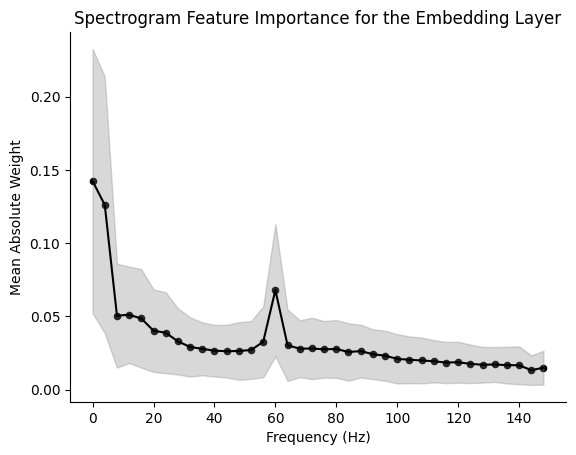

In [23]:
linear_weights = training_setup.model.fft_preprocessor.output_transform.weight.detach().cpu().numpy() # shape: (192, 38)
linear_weights_abs = np.abs(linear_weights.T)
mean_weights = linear_weights_abs.mean(axis=1)
std_weights = linear_weights_abs.std(axis=1)

freq_bins = torch.fft.rfftfreq(512, d=1.0/2048).cpu().numpy()[:38]

from matplotlib import pyplot as plt
plt.plot(freq_bins, mean_weights, color='black')
plt.scatter(freq_bins, mean_weights, color='black', s=20)
plt.fill_between(freq_bins, mean_weights - std_weights, mean_weights + std_weights, color='gray', alpha=0.3)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Mean Absolute Weight')
plt.title('Spectrogram Feature Importance for the Embedding Layer')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.show()

In [24]:
freq_bins

array([  0.,   4.,   8.,  12.,  16.,  20.,  24.,  28.,  32.,  36.,  40.,
        44.,  48.,  52.,  56.,  60.,  64.,  68.,  72.,  76.,  80.,  84.,
        88.,  92.,  96., 100., 104., 108., 112., 116., 120., 124., 128.,
       132., 136., 140., 144., 148.], dtype=float32)

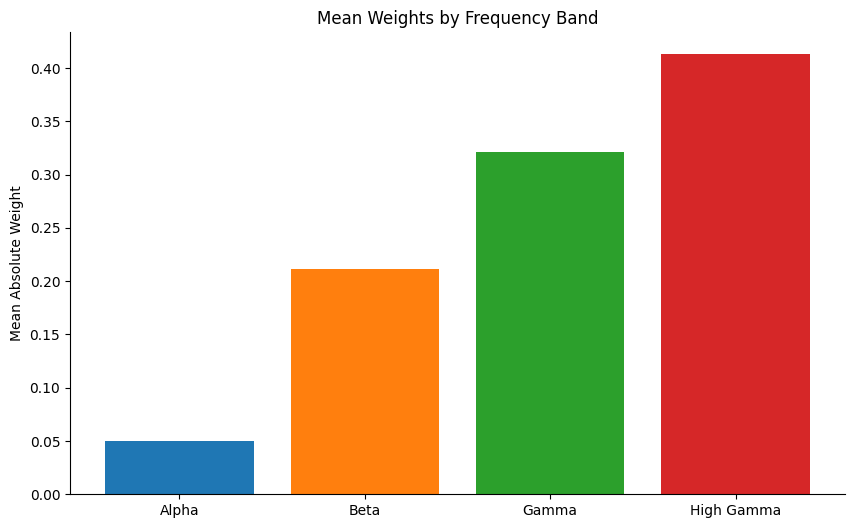

In [21]:
linear_weights = training_setup.model.fft_preprocessor.output_transform.weight.detach().cpu().numpy() # shape: (192, 38)
linear_weights_abs = np.abs(linear_weights.T)
mean_weights = linear_weights_abs.mean(axis=1)

freq_bins = torch.fft.rfftfreq(512, d=1.0/2048).cpu().numpy()[:38]

# Define frequency bands
bands = {
    'Alpha': (8, 12),
    'Beta': (12, 30), 
    'Gamma': (30, 70),
    'High Gamma': (70, 1024) # Using 1024 as upper bound since it's half the sampling rate
}

# Calculate mean weights in each band
band_weights = {}
for band_name, (low_freq, high_freq) in bands.items():
    mask = (freq_bins >= low_freq) & (freq_bins < high_freq)
    if any(mask): # Only include band if we have frequencies in that range
        band_weights[band_name] = mean_weights[mask].sum()
    else:
        band_weights[band_name] = 0

# Create bar plot
from matplotlib import pyplot as plt
plt.figure(figsize=(10, 6))
plt.bar(band_weights.keys(), band_weights.values(), color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
plt.ylabel('Mean Absolute Weight')
plt.title('Mean Weights by Frequency Band')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.show()